**Data Collection & Understanding:**
Upload dataset from Kaggle IEEE-CIS Fraud Detection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

base_path = '/content/drive/MyDrive/2025-2026 AIM Postgrad Diploma in AI & ML/Capstone Fraud Data Set/Train Data/'

train_trans = pd.read_csv(base_path + 'train_transaction.csv')
train_id = pd.read_csv(base_path + 'train_identity.csv')

train = train_trans.merge(train_id, on='TransactionID', how='left')
print(train.shape)
train.head()

Mounted at /content/drive
(590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


**Data Collection & Understanding:**
Dataset overview

In [ ]:
print("Shape:", train.shape)
print("\nMemory usage: {:.2f} MB".format(train.memory_usage(deep=True).sum() / 1024**2))

print("\nFraud rate:")
print(train['isFraud'].value_counts(normalize=True).rename({0: 'Not Fraud', 1: 'Fraud'}))

print("\nColumn dtypes:")
print(train.dtypes.value_counts())

print("\nTop 20 columns by % missing:")
missing_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
print(missing_pct.head(20))

print("\nNumeric summary (key columns):")
train[['TransactionAmt', 'TransactionDT']].describe()

Shape: (590540, 434)

Memory usage: 2513.97 MB

Fraud rate:
isFraud
Not Fraud    0.96501
Fraud        0.03499
Name: proportion, dtype: float64

Column dtypes:
float64    399
object      31
int64        4
Name: count, dtype: int64

Top 20 columns by % missing:
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_09    87.312290
dtype: float64

Numeric summary (key columns):


,TransactionAmt,TransactionDT
count,590540.000000,5.905400e+05
mean,135.027176,7.372311e+06
std,239.162522,4.617224e+06
min,0.251000,8.640000e+04
25%,43.321000,3.027058e+06
50%,68.769000,7.306528e+06
75%,125.000000,1.124662e+07
max,31937.391000,1.581113e+07


**Data Collection & Understanding:**
Data dictionary

In [ ]:
data_dictionary = pd.DataFrame([
    ("TransactionID", "Transaction", "Unique transaction identifier — join key with identity table"),
    ("isFraud", "Transaction", "Target label: 1 = fraud, 0 = legit"),
    ("TransactionDT", "Transaction", "Timedelta from a reference date (not a real timestamp)"),
    ("TransactionAmt", "Transaction", "Transaction amount in USD"),
    ("ProductCD", "Transaction", "Product code for the transaction"),
    ("card1-card6", "Transaction", "Payment card info: type, category, issuing bank, country"),
    ("addr1, addr2", "Transaction", "Address fields (purchaser region/country)"),
    ("dist1, dist2", "Transaction", "Distance fields (e.g. billing vs. shipping address)"),
    ("P_emaildomain", "Transaction", "Purchaser email domain"),
    ("R_emaildomain", "Transaction", "Recipient email domain"),
    ("C1-C14", "Transaction", "Counting features (e.g. # addresses linked to card) — masked meaning"),
    ("D1-D15", "Transaction", "Timedelta features (e.g. days since previous transaction) — masked"),
    ("M1-M9", "Transaction", "Match flags (e.g. does name match address) — masked"),
    ("V1-V339", "Transaction", "Vesta-engineered features: rankings, counts, entity relations — masked"),
    ("id_01-id_38", "Identity", "Network/device identity signals (IP, ISP, proxy, resolution, etc.) — masked"),
    ("DeviceType", "Identity", "Mobile or desktop"),
    ("DeviceInfo", "Identity", "Device/browser string"),
], columns=["Column(s)", "Table", "Description"])

data_dictionary

,Column(s),Table,Description
0,TransactionID,Transaction,Unique transaction identifier — join key with ...
1,isFraud,Transaction,"Target label: 1 = fraud, 0 = legit"
2,TransactionDT,Transaction,Timedelta from a reference date (not a real ti...
3,TransactionAmt,Transaction,Transaction amount in USD
4,ProductCD,Transaction,Product code for the transaction
5,card1-card6,Transaction,"Payment card info: type, category, issuing ban..."
6,"addr1, addr2",Transaction,Address fields (purchaser region/country)
7,"dist1, dist2",Transaction,Distance fields (e.g. billing vs. shipping add...
8,P_emaildomain,Transaction,Purchaser email domain
9,R_emaildomain,Transaction,Recipient email domain


**Data Collection & Understanding:**
Identifying ouliers

Outlier summary (IQR method):

TransactionAmt  | range seen: [0.3, 31937.4] | normal range: [-79.2, 247.5] | outliers: 66482 (11.26%)
card1           | range seen: [1000.0, 18396.0] | normal range: [-6228.5, 26431.5] | outliers: 0 (0.00%)
addr1           | range seen: [100.0, 540.0] | normal range: [15.0, 519.0] | outliers: 369 (0.07%)
dist1           | range seen: [0.0, 10286.0] | normal range: [-28.5, 55.5] | outliers: 39981 (16.78%)
dist2           | range seen: [0.0, 11623.0] | normal range: [-291.5, 504.5] | outliers: 4710 (12.52%)

Top 5 'C' columns by outlier %:
  C14: 16.27%
  C6: 13.26%
  C13: 12.81%
  C11: 12.67%
  C2: 10.54%

Top 5 'D' columns by outlier %:
  D14: 23.39%
  D12: 21.24%
  D6: 20.26%
  D7: 18.44%
  D5: 13.45%

Top 5 'V' columns by outlier %:
  V332: 21.00%
  V204: 19.20%
  V265: 19.04%
  V203: 18.41%
  V264: 17.99%


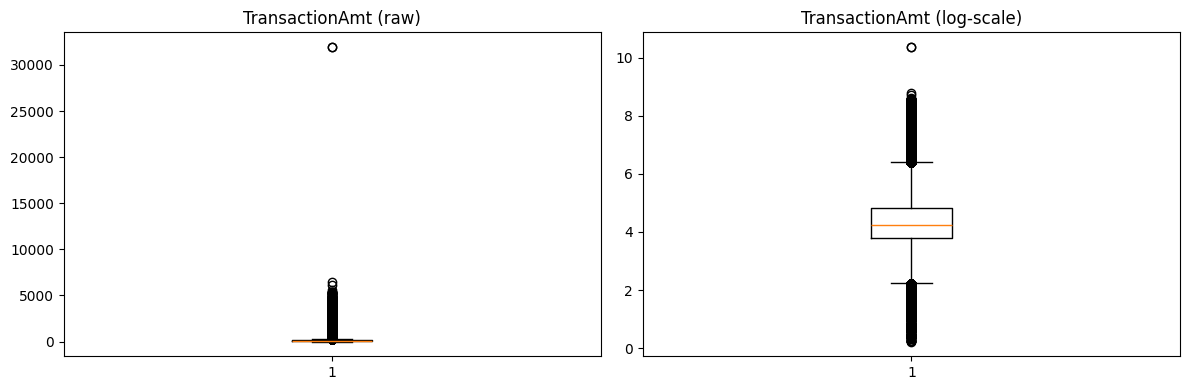

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. IQR-based outlier scan on the most interpretable numeric columns
key_numeric_cols = ['TransactionAmt', 'card1', 'addr1', 'dist1', 'dist2']

print("Outlier summary (IQR method):\n")
for col in key_numeric_cols:
    if col not in train.columns:
        continue
    data = train[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((data < lower) | (data > upper)).sum()
    pct = n_outliers / len(data) * 100
    print(f"{col:15s} | range seen: [{data.min():.1f}, {data.max():.1f}] | "
          f"normal range: [{lower:.1f}, {upper:.1f}] | outliers: {n_outliers} ({pct:.2f}%)")

# 2. Same scan across the masked engineered groups (C, D, V) — flag which have the most extreme skew
for prefix in ['C', 'D', 'V']:
    cols = [c for c in train.columns if c.startswith(prefix) and c[1:].isdigit()]
    outlier_pcts = {}
    for col in cols:
        data = train[col].dropna()
        if len(data) == 0:
            continue
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        if IQR == 0:
            continue
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outlier_pcts[col] = ((data < lower) | (data > upper)).mean() * 100
    if outlier_pcts:
        top5 = sorted(outlier_pcts.items(), key=lambda x: -x[1])[:5]
        print(f"\nTop 5 '{prefix}' columns by outlier %:")
        for col, pct in top5:
            print(f"  {col}: {pct:.2f}%")

# 3. Visualize the one column that's actually interpretable in business terms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(train['TransactionAmt'].dropna())
axes[0].set_title('TransactionAmt (raw)')
axes[1].boxplot(np.log1p(train['TransactionAmt'].dropna()))
axes[1].set_title('TransactionAmt (log-scale)')
plt.tight_layout()
plt.show()

**Data Collection & Understanding:**
Data dictionary with Type and Allowed Values

In [ ]:
import numpy as np # Import numpy for numeric type checking

def get_allowed_values(col_or_prefix, is_group=False):
    if is_group:
        cols = [c for c in train.columns if c.startswith(col_or_prefix) and c[len(col_or_prefix):].isdigit()]
        if not cols:
            return "N/A", "N/A"
        dtype_str = "/".join(sorted(set(str(d) for d in train[cols].dtypes)))

        numeric_cols = train[cols].select_dtypes(include=np.number).columns
        object_cols = [c for c in cols if c not in numeric_cols]

        parts = []
        if len(numeric_cols) > 0:
            vmin = train[numeric_cols].min().min()
            vmax = train[numeric_cols].max().max()
            parts.append(f"continuous, range [{vmin:.1f}, {vmax:.1f}]")
        if object_cols:
            sample_vals = pd.unique(train[object_cols].values.ravel())
            sample_vals = [v for v in sample_vals if pd.notna(v)][:8]
            parts.append(f"categorical, e.g. {list(sample_vals)}")

        return dtype_str, "; ".join(parts) if parts else "N/A"
    else:
        dtype = str(train[col_or_prefix].dtype)
        vals = train[col_or_prefix].dropna().unique()
        if train[col_or_prefix].dtype == 'object' or len(vals) <= 15:
            allowed = ", ".join(sorted(map(str, vals))[:15])
        else:
            allowed = f"range [{train[col_or_prefix].min():.1f}, {train[col_or_prefix].max():.1f}]"
        return dtype, allowed

rows = []

# Interpretable single columns — pull real dtype + values from the data
single_cols = {
    "TransactionID": ("Transaction", "Unique transaction identifier — join key with identity table"),
    "isFraud": ("Transaction", "Target label"),
    "TransactionDT": ("Transaction", "Timedelta from a reference date (not a real timestamp)"),
    "TransactionAmt": ("Transaction", "Transaction amount (USD)"),
    "ProductCD": ("Transaction", "Product code for the transaction"),
    "card4": ("Transaction", "Card network"),
    "card6": ("Transaction", "Card category"),
    "addr1": ("Transaction", "Billing region code"),
    "addr2": ("Transaction", "Billing country code"),
    "P_emaildomain": ("Transaction", "Purchaser email domain"),
    "R_emaildomain": ("Transaction", "Recipient email domain"),
    "DeviceType": ("Identity", "Mobile or desktop"),
}

for col, (table, desc) in single_cols.items():
    if col not in train.columns:
        continue
    dtype, allowed = get_allowed_values(col)
    rows.append((col, table, dtype, allowed, desc))

# Masked engineered groups — dtype + numeric range pulled from actual data
group_defs = {
    "card1-card3, card5": ("Transaction", "Payment card numeric identifiers/scores — masked"),
    "dist1": ("Transaction", "Distance metric — masked units"),
    "dist2": ("Transaction", "Distance metric — masked units"),
    "C": ("Transaction", "Counting features (e.g. # addresses linked to card) — masked meaning"),
    "D": ("Transaction", "Timedelta features (e.g. days since previous transaction) — masked"),
    "M": ("Transaction", "Match flags (e.g. name/address match) — masked, categorical T/F"),
    "V": ("Transaction", "Vesta-engineered features: rankings, counts, entity relations — masked"),
    "id_": ("Identity", "Network/device identity signals (IP, ISP, proxy, resolution, etc.) — masked"),
}

for prefix, (table, desc) in group_defs.items():
    if prefix in ["card1-card3, card5", "dist1", "dist2"]:
        continue  # already covered individually or too irregular to group cleanly
    dtype, allowed = get_allowed_values(prefix, is_group=True)
    rows.append((f"{prefix}*", table, dtype, allowed, desc))

data_dictionary = pd.DataFrame(rows, columns=["Column(s)", "Table", "Type", "Allowed Values / Range", "Description"])
data_dictionary

,Column(s),Table,Type,Allowed Values / Range,Description
0,TransactionID,Transaction,int64,"range [2987000.0, 3577539.0]",Unique transaction identifier — join key with ...
1,isFraud,Transaction,int64,"0, 1",Target label
2,TransactionDT,Transaction,int64,"range [86400.0, 15811131.0]",Timedelta from a reference date (not a real ti...
3,TransactionAmt,Transaction,float64,"range [0.3, 31937.4]",Transaction amount (USD)
4,ProductCD,Transaction,object,"C, H, R, S, W",Product code for the transaction
5,card4,Transaction,object,"american express, discover, mastercard, visa",Card network
6,card6,Transaction,object,"charge card, credit, debit, debit or credit",Card category
7,addr1,Transaction,float64,"range [100.0, 540.0]",Billing region code
8,addr2,Transaction,float64,"range [10.0, 102.0]",Billing country code
9,P_emaildomain,Transaction,object,"aim.com, anonymous.com, aol.com, att.net, bell...",Purchaser email domain


**Data Collection & Understanding:**
Docu write-up content

In [ ]:
# Data for  write-up template
fields = {
    "TransactionID": ["TransactionID"],
    "isFraud": ["isFraud"],
    "TransactionAmt": ["TransactionAmt"],
    "P_emaildomain / R_emaildomain": ["P_emaildomain", "R_emaildomain"],
    "addr1 / addr2": ["addr1", "addr2"],
    "DeviceType / DeviceInfo": ["DeviceType", "DeviceInfo"],
    "card1-card6": [f"card{i}" for i in range(1, 7)],
    "id_01 - id_38": [f"id_{i:02d}" for i in range(1, 39)],
}

print(f"{'Field':35s} | Missing %\n" + "-"*55)
for label, cols in fields.items():
    cols = [c for c in cols if c in train.columns]
    pct = (train[cols].isnull().sum() / len(train) * 100)
    if len(cols) == 1:
        print(f"{label:35s} | {pct.iloc[0]:.1f}%")
    else:
        print(f"{label:35s} | range [{pct.min():.1f}%, {pct.max():.1f}%], avg {pct.mean():.1f}%")

Field                               | Missing %
-------------------------------------------------------
TransactionID                       | 0.0%
isFraud                             | 0.0%
TransactionAmt                      | 0.0%
P_emaildomain / R_emaildomain       | range [16.0%, 76.8%], avg 46.4%
addr1 / addr2                       | range [11.1%, 11.1%], avg 11.1%
DeviceType / DeviceInfo             | range [76.2%, 79.9%], avg 78.0%
card1-card6                         | range [0.0%, 1.5%], avg 0.5%
id_01 - id_38                       | range [75.6%, 99.2%], avg 84.8%


In [ ]:
fields_extra = {
    "C1-C14": [f"C{i}" for i in range(1, 15)],
    "D1-D15": [f"D{i}" for i in range(1, 16)],
    "M1-M9": [f"M{i}" for i in range(1, 10)],
    "V1-V339": [f"V{i}" for i in range(1, 340)],
    "dist1": ["dist1"],
}

print(f"{'Field':15s} | Missing %\n" + "-"*40)
for label, cols in fields_extra.items():
    cols = [c for c in cols if c in train.columns]
    pct = (train[cols].isnull().sum() / len(train) * 100)
    if len(cols) == 1:
        print(f"{label:15s} | {pct.iloc[0]:.2f}%")
    else:
        print(f"{label:15s} | range [{pct.min():.2f}%, {pct.max():.2f}%], avg {pct.mean():.2f}%")

Field           | Missing %
----------------------------------------
C1-C14          | range [0.00%, 0.00%], avg 0.00%
D1-D15          | range [0.21%, 93.41%], avg 58.15%
M1-M9           | range [28.68%, 59.35%], avg 49.92%
V1-V339         | range [0.00%, 86.12%], avg 43.04%
dist1           | 59.65%


In [ ]:
# Save the merged dataframe to the same Drive folder used for the raw CSVs
train.to_parquet(base_path + "train_transaction_identity.parquet", index=False)

print("Saved to:", base_path)

Saved to: /content/drive/MyDrive/2025-2026 AIM Postgrad Diploma in AI & ML/Capstone Fraud Data Set/Train Data/
